<a href="https://colab.research.google.com/github/RafayRizwan023/Deep_Learning_Labs_Raf023/blob/main/Lab03%20Code%20Files%5CLab3_MNIST_DATA_Tutorial_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import mnist


In [ ]:
# Step 1: Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()  # Load the dataset

# Normalize the pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0  # Scale training data
x_test = x_test.astype('float32') / 255.0  # Scale test data

# One-hot encode the labels (0-9) for categorical classification
y_train = to_categorical(y_train, 10)  # Encode training labels
y_test = to_categorical(y_test, 10)  # Encode test labels

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Step 2: Build the neural network model
model = Sequential([
    Flatten(input_shape=(28, 28)),  # Flatten 28x28 images to a 1D vector of 784 features
    Dense(128, activation='relu'),  # Hidden layer with 128 neurons and ReLU activation
    Dense(64, activation='relu'),  # Hidden layer with 64 neurons and ReLU activation
    Dense(10, activation='softmax')  # Output layer with 10 neurons and softmax activation
])

# Print the model summary to understand the architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 3: Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
# Step 4: Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
# Step 5: Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")  # Print the test accuracy

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9177 - loss: 0.2752 - val_accuracy: 0.9555 - val_loss: 0.1498
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9656 - loss: 0.1144 - val_accuracy: 0.9655 - val_loss: 0.1147
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9758 - loss: 0.0801 - val_accuracy: 0.9706 - val_loss: 0.0948
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9814 - loss: 0.0584 - val_accuracy: 0.9696 - val_loss: 0.1007
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9853 - loss: 0.0456 - val_accuracy: 0.9727 - val_loss: 0.1044
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9885 - loss: 0.0353 - val_accuracy: 0.9732 - val_loss: 0.0994
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9896 - loss: 0.0305 - val_accuracy: 0.9735 - val_loss: 0.1058
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9920 - loss: 0.0240 

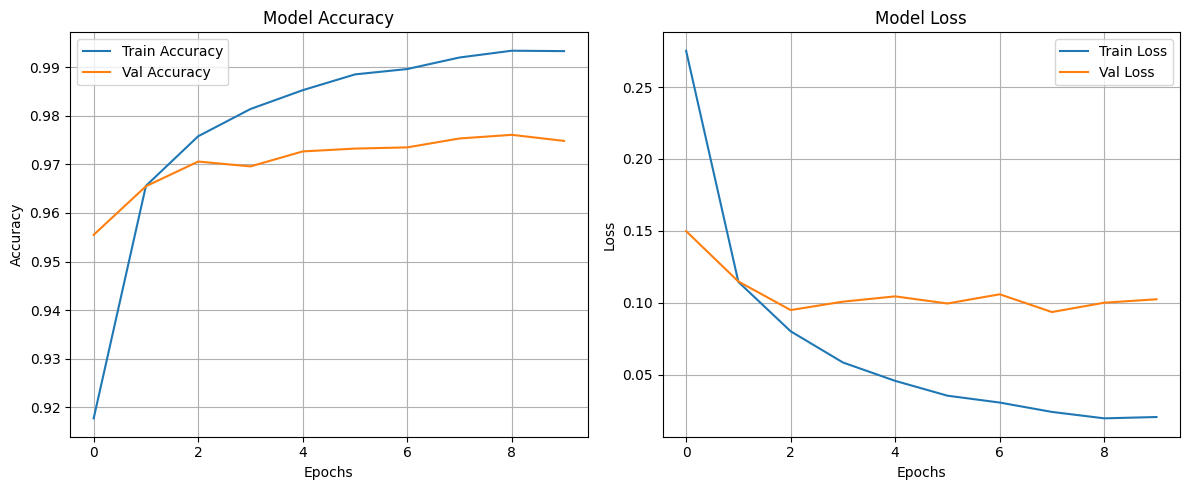

In [ ]:
# Step 6: Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 5))  # Create a figure with a specific size

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)  # Create a subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')  # Plot training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')  # Plot validation accuracy
plt.title('Model Accuracy')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Accuracy')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create a subplot for loss
plt.plot(history.history['loss'], label='Train Loss')  # Plot training loss
plt.plot(history.history['val_loss'], label='Val Loss')  # Plot validation loss
plt.title('Model Loss')  # Set the title
plt.xlabel('Epochs')  # Set x-axis label
plt.ylabel('Loss')  # Set y-axis label
plt.legend()  # Show legend
plt.grid()  # Add grid lines

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the plots

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


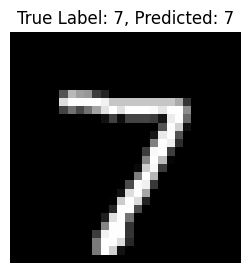

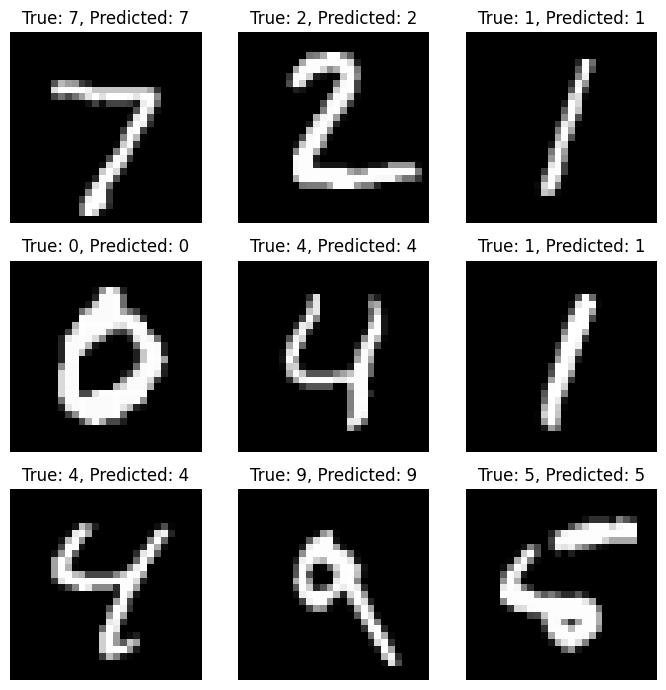

In [ ]:
# Step 7: Make predictions on the test set
predictions = model.predict(x_test)

# Display the first test image and its predicted label
plt.figure(figsize=(3, 3))  # Create a figure for the image
plt.imshow(x_test[0], cmap='gray')  # Show the first test image in grayscale
plt.title(f"True Label: {np.argmax(y_test[0])}, Predicted: {np.argmax(predictions[0])}")  # Display true and predicted labels
plt.axis('off')  # Hide the axis
plt.show()  # Display the image

# Display a grid of images with true and predicted labels
num_images = 9  # Number of images to display
plt.figure(figsize=(7, 7))  # Create a figure for the grid of images

for i in range(num_images):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    plt.imshow(x_test[i], cmap='gray')  # Show each test image in grayscale
    plt.title(f"True: {np.argmax(y_test[i])}, Predicted: {np.argmax(predictions[i])}")  # Display true and predicted labels
    plt.axis('off')  # Hide the axis

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()  # Display the grid of images